# Machine Learning Classification in GeoWombat

This notebook demonstrates machine learning classification for remote sensing
data using **geowombat** and **scikit-learn**. It covers:

1. Supervised classification (fit/predict and fit_predict)
2. Unsupervised classification (KMeans)
3. Time series stacking with `stack_dim='band'`
4. Cross-validation & hyperparameter tuning
5. Time-dimensioned data with `temporal_mode='panel'` and `temporal_mode='flatten'`

**Requirements:** `pip install geowombat[ml]`

Based on the [pygis tutorial](https://pygis.io/docs/f_rs_ml_predict.html).

---
## Setup

In [1]:
import os
os.environ['CPL_LOG'] = '/dev/null'  # suppress GDAL warnings

import warnings

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler

import geowombat as gw
from geowombat.data import (
    l8_224078_20200518,
    l8_224078_20200518_points,
    stac_training,
)
from geowombat.ml import fit, fit_predict, predict

warnings.filterwarnings('ignore', category=(DeprecationWarning))
warnings.filterwarnings('ignore', category=(FutureWarning))
warnings.filterwarnings('ignore', category=(UserWarning))

/home/mmann1123/miniconda3/envs/geowombat_dev/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load training data

We use labeled polygons and points bundled with geowombat. The polygon labels
in `stac_training` have an integer `lc` column. The point labels use string
class names that we encode with `LabelEncoder`.

In [2]:
# Polygon labels (integer 'lc' column, EPSG:4326)
labels_poly = gpd.read_file(stac_training)
print('Polygon labels:')
print(f"  CRS: {labels_poly.crs}")
print(f"  Classes: {sorted(labels_poly['lc'].unique())}")
print(labels_poly[['lc', 'geometry']].head())

# Point labels (need LabelEncoder for string names)
le = LabelEncoder()
labels_point = gpd.read_file(l8_224078_20200518_points)
labels_point['lc'] = le.fit(labels_point.name).transform(labels_point.name)
labels_point = labels_point.drop(columns=['name'])
print('\nPoint labels:')
print(labels_point.head())

Polygon labels:
  CRS: EPSG:4326
  Classes: [0, 1, 2, 3, 5]
   lc                                           geometry
0   0  POLYGON ((-54.64919 -25.25946, -54.64925 -25.2...
1   0  POLYGON ((-54.62817 -25.27092, -54.62803 -25.2...
2   2  POLYGON ((-54.6147 -25.27095, -54.60949 -25.26...
3   1  POLYGON ((-54.61715 -25.28278, -54.62002 -25.2...
4   1  POLYGON ((-54.58943 -25.32398, -54.58966 -25.3...

Point labels:
                          geometry  lc
0  POINT (741522.314 -2811204.698)   3
1  POINT (736140.845 -2806478.364)   0
2  POINT (745919.508 -2805168.579)   2
3  POINT (739056.735 -2811710.662)   1
4  POINT (737802.183 -2818016.412)   3


---
## 1. Supervised Classification

Build a sklearn `Pipeline` with StandardScaler → PCA → GaussianNB, then
train and predict on a Landsat 8 image.

### Using `fit()` then `predict()` (two-step)

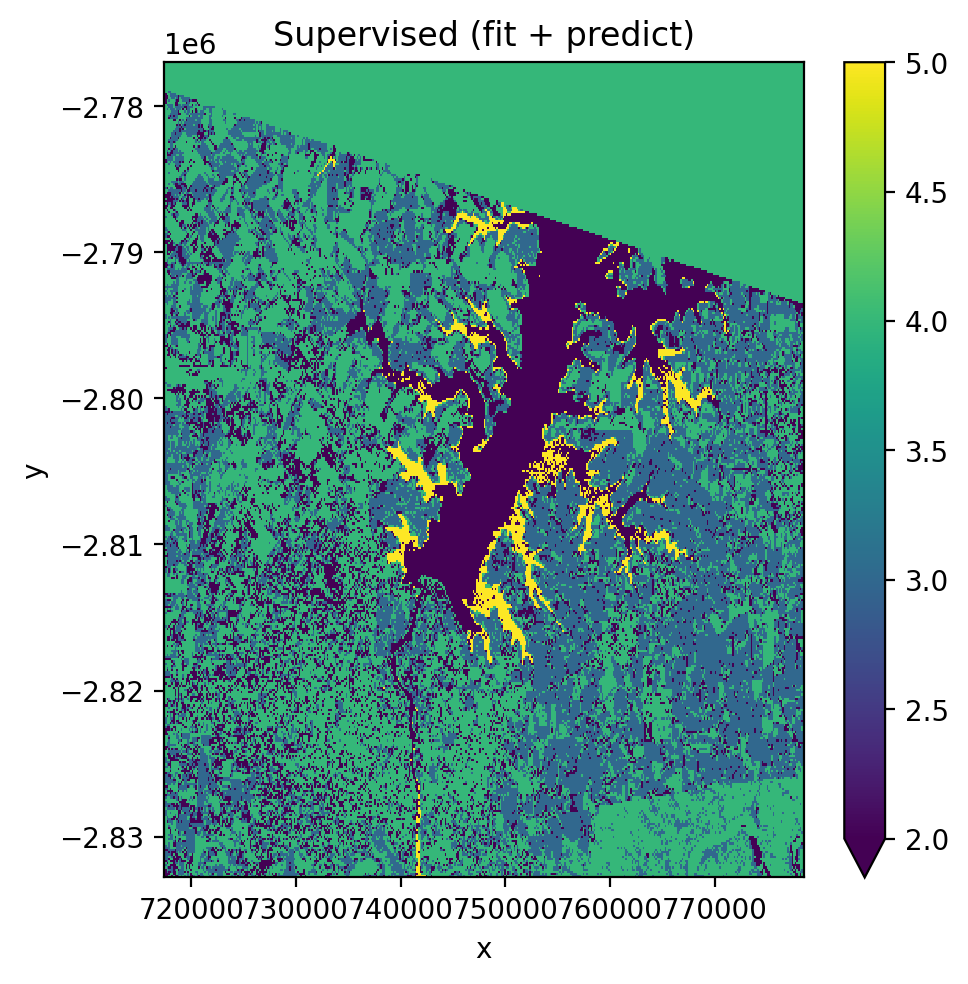

In [3]:
pl = Pipeline(
    [
        ('scaler', StandardScaler()),
        ('pca', PCA()),
        ('clf', GaussianNB()),
    ]
)

fig, ax = plt.subplots(dpi=200, figsize=(5, 5))

with gw.config.update(ref_res=150):
    with gw.open(l8_224078_20200518, nodata=0) as src:
        X, Xy, clf = fit(src, pl, labels_poly, col='lc')
        y = predict(src, X, clf)
        y.plot(robust=True, ax=ax)

ax.set_title('Supervised (fit + predict)')
plt.tight_layout(pad=1)
plt.show()

### Using `fit_predict()` (one-step)

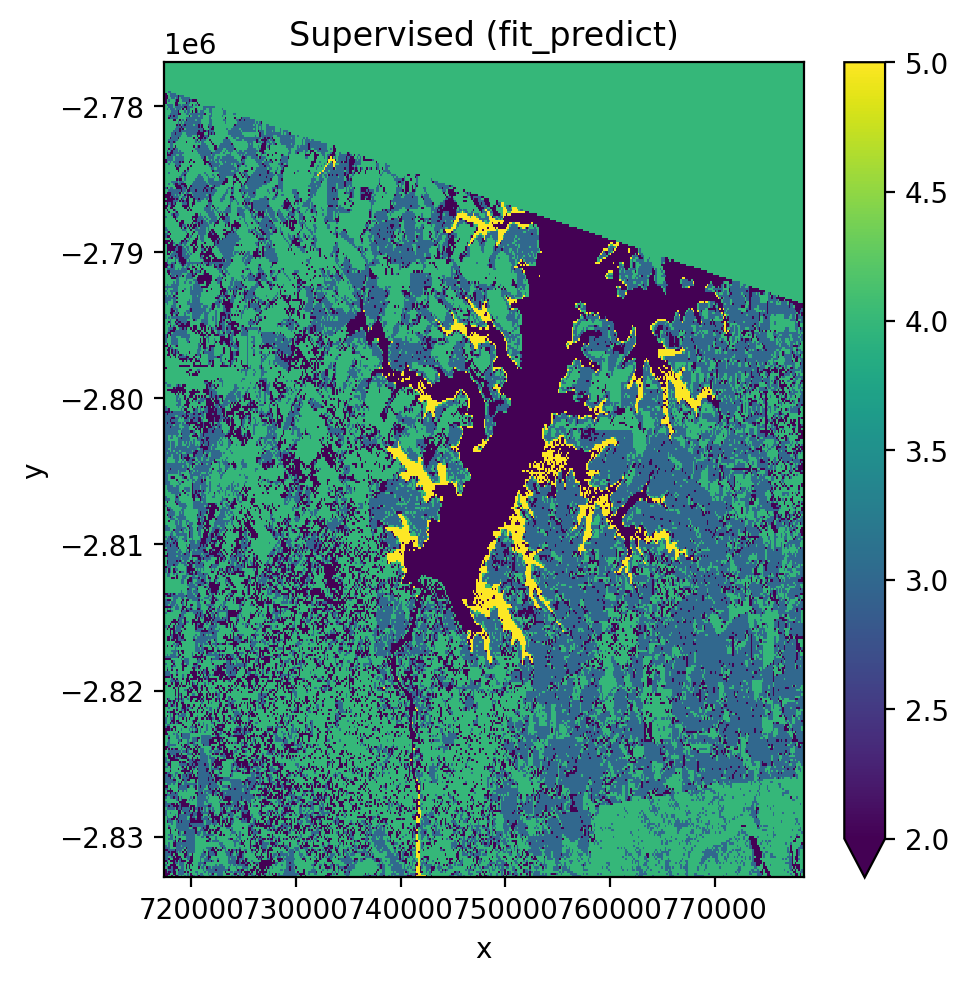

In [4]:
fig, ax = plt.subplots(dpi=200, figsize=(5, 5))

with gw.config.update(ref_res=150):
    with gw.open(l8_224078_20200518, nodata=0) as src:
        y = fit_predict(src, pl, labels_poly, col='lc')
        y.plot(robust=True, ax=ax)

ax.set_title('Supervised (fit_predict)')
plt.tight_layout(pad=1)
plt.show()

---
## 2. Unsupervised Classification (KMeans)

No training labels needed. The algorithm identifies clusters directly from
the pixel values.

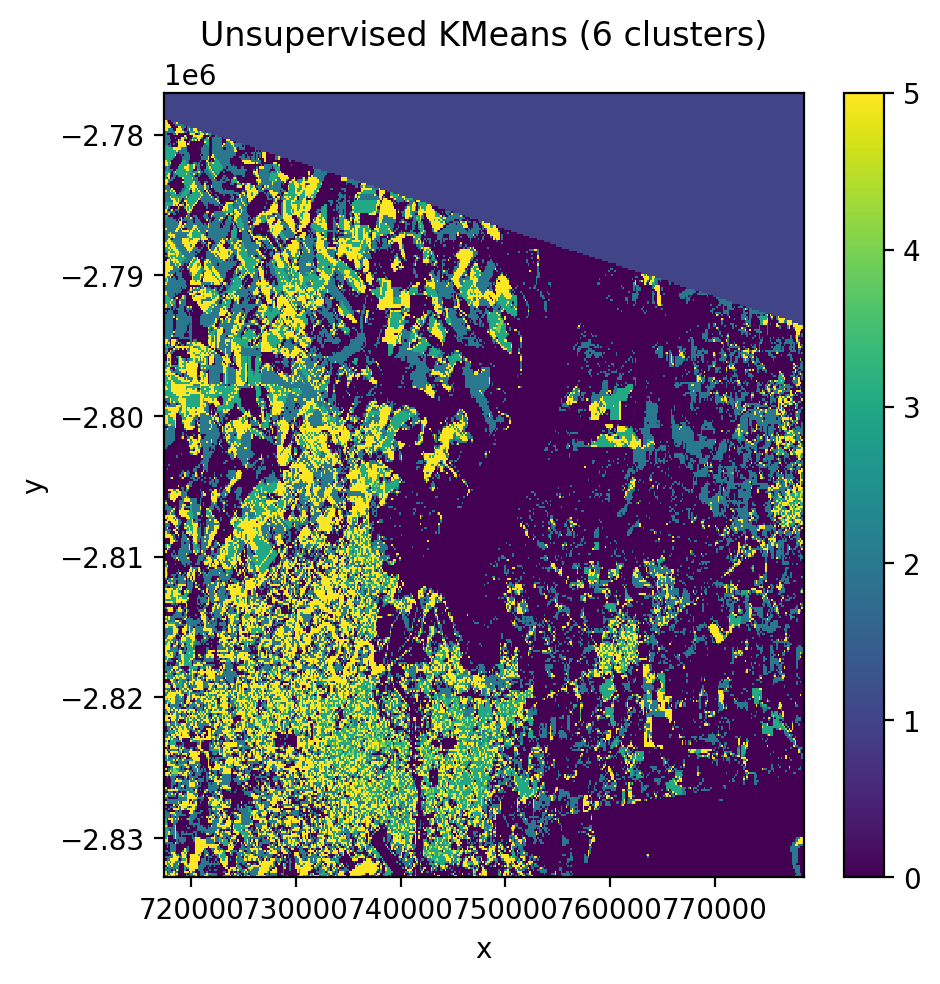

In [5]:
cl = Pipeline([('clf', KMeans(n_clusters=6, random_state=0))])

fig, ax = plt.subplots(dpi=200, figsize=(5, 5))

with gw.config.update(ref_res=150):
    with gw.open(l8_224078_20200518, nodata=0) as src:
        y = fit_predict(src, cl)
        y.plot(robust=True, ax=ax)

ax.set_title('Unsupervised KMeans (6 clusters)')
plt.tight_layout(pad=1)
plt.show()

---
## 3. Time Series Stacking with `stack_dim='band'`

Stack multiple images along the band dimension. This concatenates spectral
bands from each date into one long feature vector per pixel.

Band-stacked shape: (6, 372, 408)
Dims: ('band', 'y', 'x')

Prediction shape: (1, 372, 408)


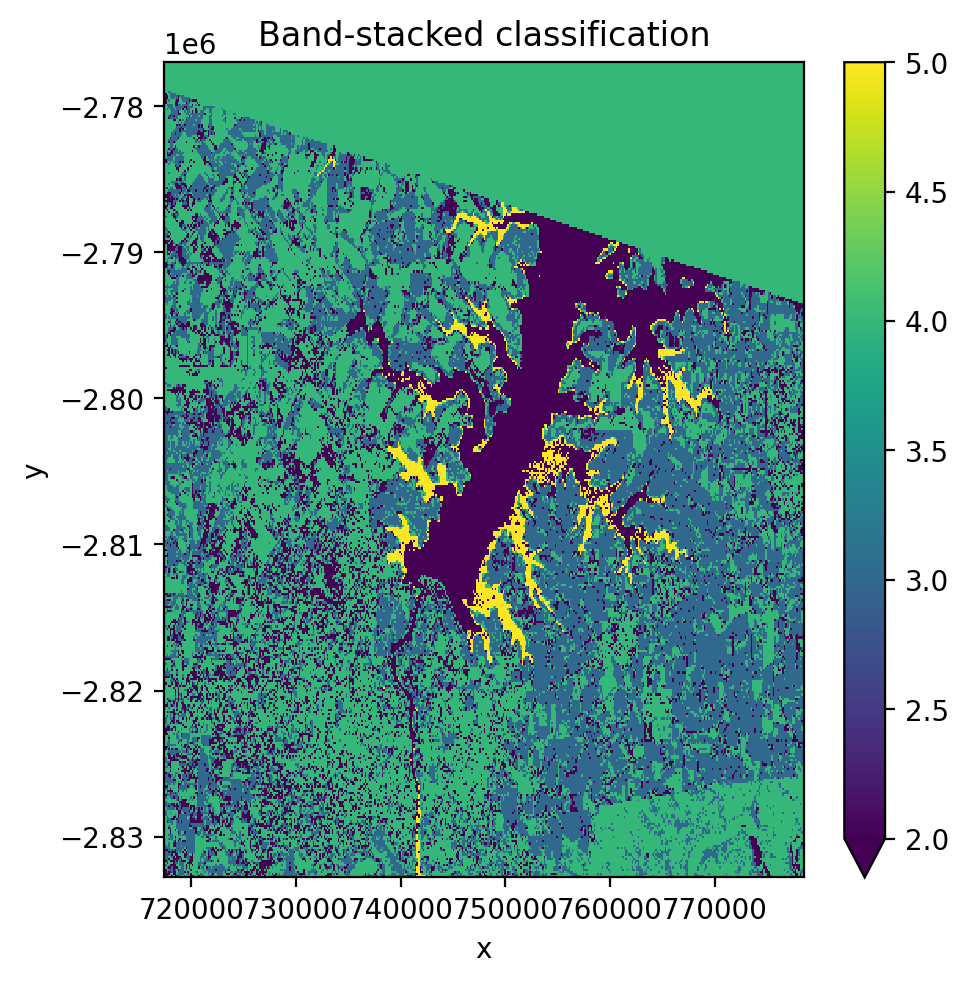

In [6]:
fig, ax = plt.subplots(dpi=200, figsize=(5, 5))

with gw.config.update(ref_res=150):
    with gw.open(
        [l8_224078_20200518, l8_224078_20200518],
        stack_dim='band',
        nodata=0,
    ) as src:
        print('Band-stacked shape:', src.shape)
        print('Dims:', src.dims)
        y = fit_predict(src, pl, labels_poly, col='lc')
        print('\nPrediction shape:', y.shape)
        y.plot(robust=True, ax=ax)

ax.set_title('Band-stacked classification')
plt.tight_layout(pad=1)
plt.show()

---
## 4. Cross-Validation & Hyperparameter Tuning

Use `GridSearchCV` with `CrossValidatorWrapper` to tune pipeline
hyperparameters.

Best score: 0.3833404538104048
Best params: {'pca__n_components': 3, 'scaler__with_std': True}


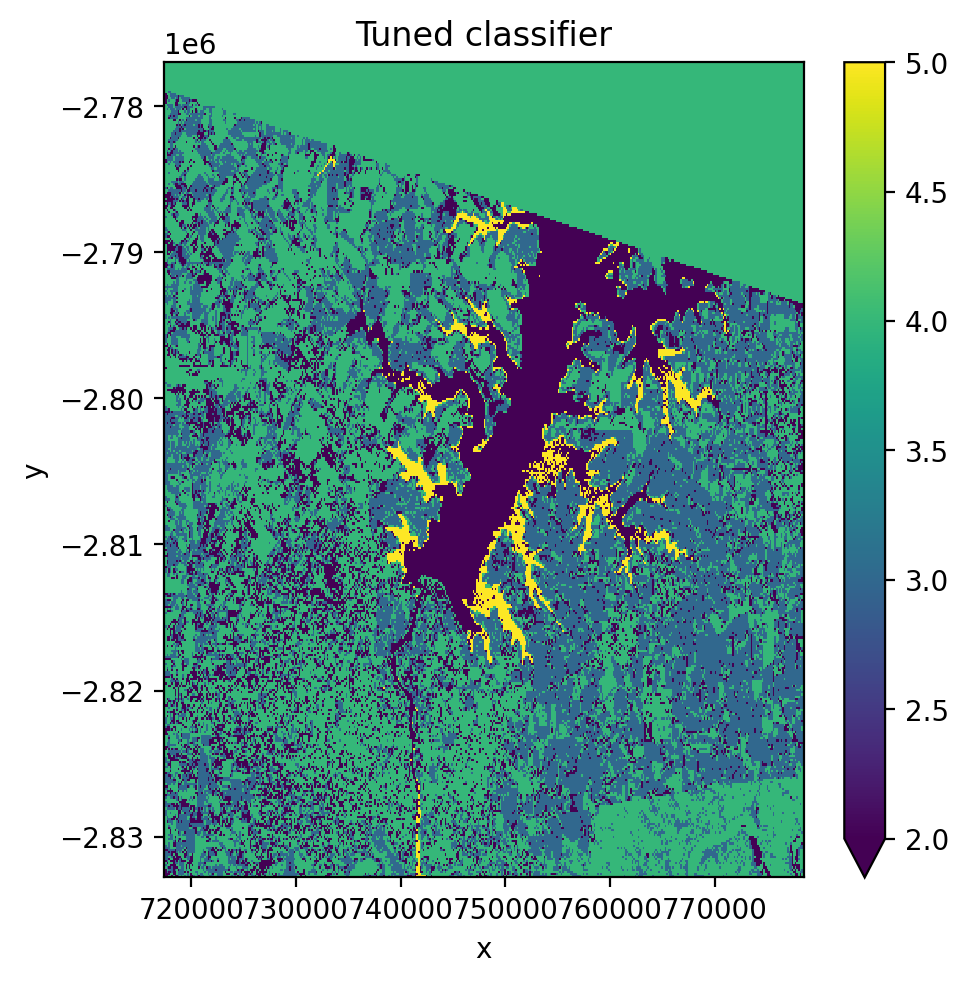

In [7]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn_xarray.model_selection import CrossValidatorWrapper

pl_cv = Pipeline(
    [
        ('scaler', StandardScaler()),
        ('pca', PCA()),
        ('clf', GaussianNB()),
    ]
)

cv = CrossValidatorWrapper(KFold())
gridsearch = GridSearchCV(
    pl_cv,
    cv=cv,
    scoring='balanced_accuracy',
    param_grid={
        'scaler__with_std': [True, False],
        'pca__n_components': [1, 2, 3],
    },
)

fig, ax = plt.subplots(dpi=200, figsize=(5, 5))

with gw.config.update(ref_res=150):
    with gw.open(l8_224078_20200518, nodata=0) as src:
        X, Xy, pipe = fit(src, pl_cv, labels_poly, col='lc')

        # Cross-validation and parameter tuning
        gridsearch.fit(*Xy)
        print('Best score:', gridsearch.best_score_)
        print('Best params:', gridsearch.best_params_)

        # Apply best parameters and predict
        pipe.set_params(**gridsearch.best_params_)
        y = predict(src, X, pipe)
        y.plot(robust=True, ax=ax)

ax.set_title('Tuned classifier')
plt.tight_layout(pad=1)
plt.show()

---
## 5. Time-Dimensioned Data with `temporal_mode`

When you open multiple images with `stack_dim='time'`, the data has shape
`(time, band, y, x)`. This is the format returned by STAC queries and
multi-date `gw.open()` calls.

The `temporal_mode` parameter controls how time is handled during
classification:

| `temporal_mode` | Samples | Features | Output shape |
|---|---|---|---|
| `'panel'` (default) | T × H × W | B | `(time, band='targ', y, x)` — one prediction per pixel per time step |
| `'flatten'` | H × W | T × B | `(band='targ', y, x)` — one prediction per pixel using all time steps as features |

### Inspect time-stacked data

In [8]:
with gw.config.update(ref_res=150):
    with gw.open(
        [l8_224078_20200518, l8_224078_20200518],
        stack_dim='time',
    ) as src:
        print('Time-stacked data:')
        print(f'  Shape: {src.shape}')
        print(f'  Dims:  {src.dims}')
        print(f'  Time coords: {src.time.values}')
        print(f'  Band coords: {src.band.values}')

Time-stacked data:
  Shape: (2, 3, 372, 408)
  Dims:  ('time', 'band', 'y', 'x')
  Time coords: [1 2]
  Band coords: [1 2 3]


### Panel mode (`temporal_mode='panel'`)

Each pixel-time combination is treated as an independent sample with B
spectral features. The output retains the time dimension, giving one
prediction map per time step.

Panel output:
  Shape: (2, 1, 372, 408)
  Dims:  ('time', 'band', 'y', 'x')
  Time dim preserved: True


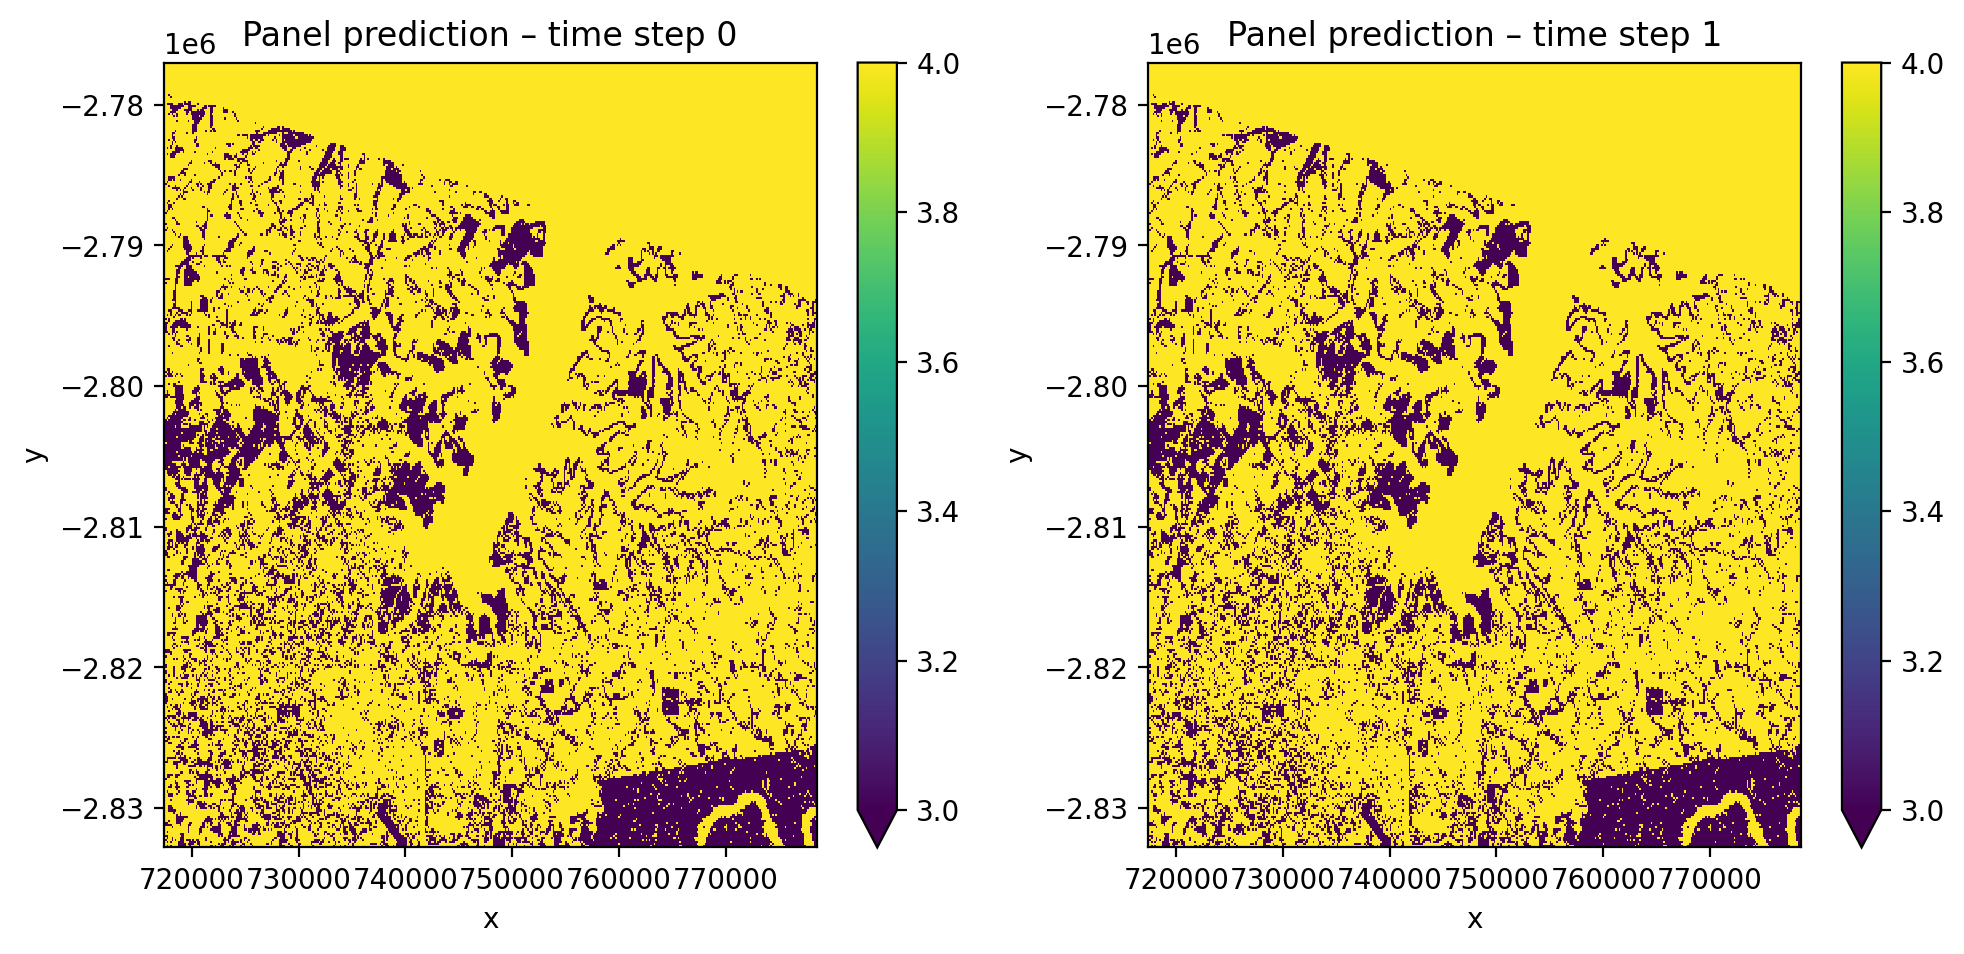


Time steps identical: True


In [9]:
pl_panel = Pipeline(
    [
        ('scaler', StandardScaler()),
        ('pca', PCA()),
        ('clf', GaussianNB()),
    ]
)

with gw.config.update(ref_res=150):
    with gw.open(
        [l8_224078_20200518, l8_224078_20200518],
        stack_dim='time',
    ) as src:
        y_panel = fit_predict(
            src,
            pl_panel,
            labels_point,
            col='lc',
            mask_nodataval=False,
            temporal_mode='panel',
        )

print('Panel output:')
print(f'  Shape: {y_panel.shape}')
print(f'  Dims:  {y_panel.dims}')
print(f'  Time dim preserved: {"time" in y_panel.dims}')

# Plot each time step
fig, axes = plt.subplots(1, 2, dpi=200, figsize=(10, 5))
for i, ax in enumerate(axes):
    y_panel.isel(time=i).plot(robust=True, ax=ax)
    ax.set_title(f'Panel prediction \u2013 time step {i}')
plt.tight_layout(pad=1)
plt.show()

# Since both time steps use the same image, predictions should match
print(
    '\nTime steps identical:',
    np.allclose(
        y_panel.isel(time=0).values,
        y_panel.isel(time=1).values,
        equal_nan=True,
    ),
)

### Flatten mode (`temporal_mode='flatten'`)

All time steps are flattened into the band dimension, creating T×B features
per pixel. This produces a single prediction map regardless of how many
time steps exist.

Flatten output:
  Shape: (1, 372, 408)
  Dims:  ('band', 'y', 'x')
  Time dim removed: True


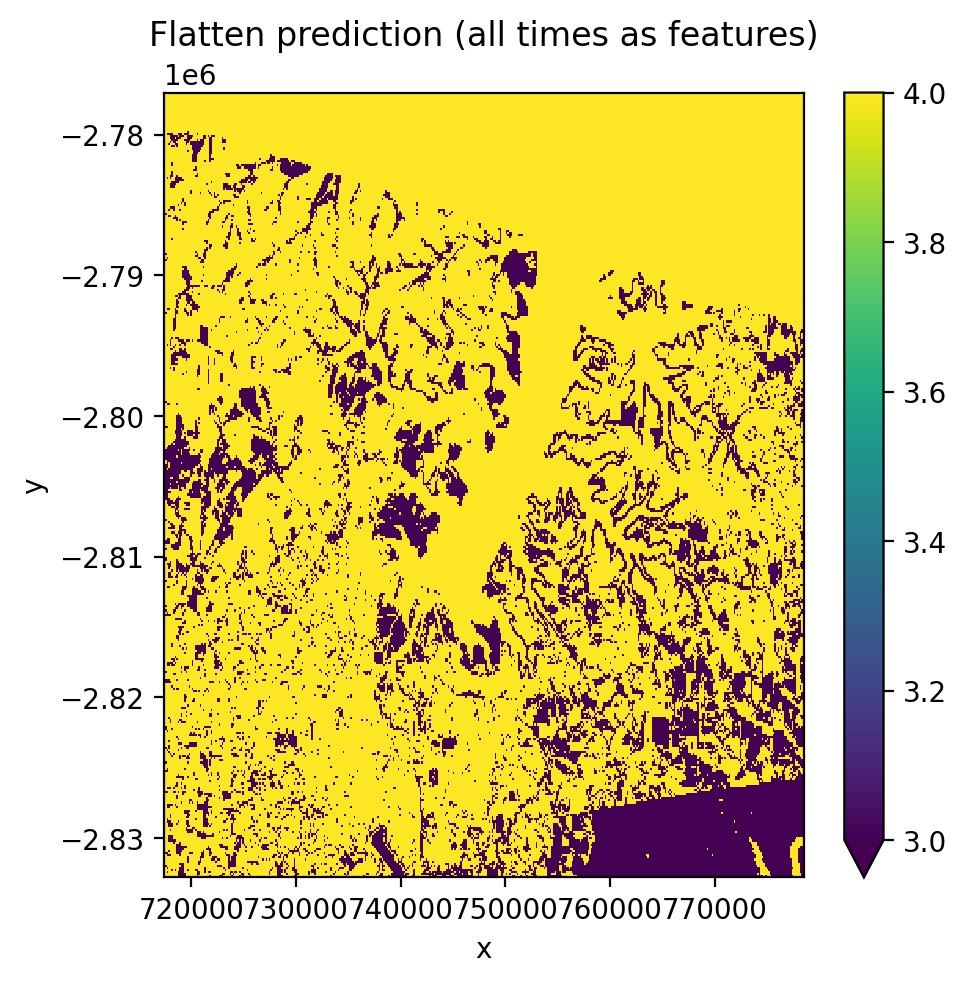

In [10]:
# Use PCA with n_components=1 since we have more features (T*B) than samples
pl_flatten = Pipeline(
    [
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=1)),
        ('clf', GaussianNB()),
    ]
)

with gw.config.update(ref_res=150):
    with gw.open(
        [l8_224078_20200518, l8_224078_20200518],
        stack_dim='time',
    ) as src:
        y_flat = fit_predict(
            src,
            pl_flatten,
            labels_point,
            col='lc',
            mask_nodataval=False,
            temporal_mode='flatten',
        )

print('Flatten output:')
print(f'  Shape: {y_flat.shape}')
print(f'  Dims:  {y_flat.dims}')
print(f'  Time dim removed: {"time" not in y_flat.dims}')

fig, ax = plt.subplots(dpi=200, figsize=(5, 5))
y_flat.plot(robust=True, ax=ax)
ax.set_title('Flatten prediction (all times as features)')
plt.tight_layout(pad=1)
plt.show()

### Unsupervised clustering with time-stacked data

Unsupervised panel output:
  Shape: (2, 1, 372, 408)
  Dims:  ('time', 'band', 'y', 'x')


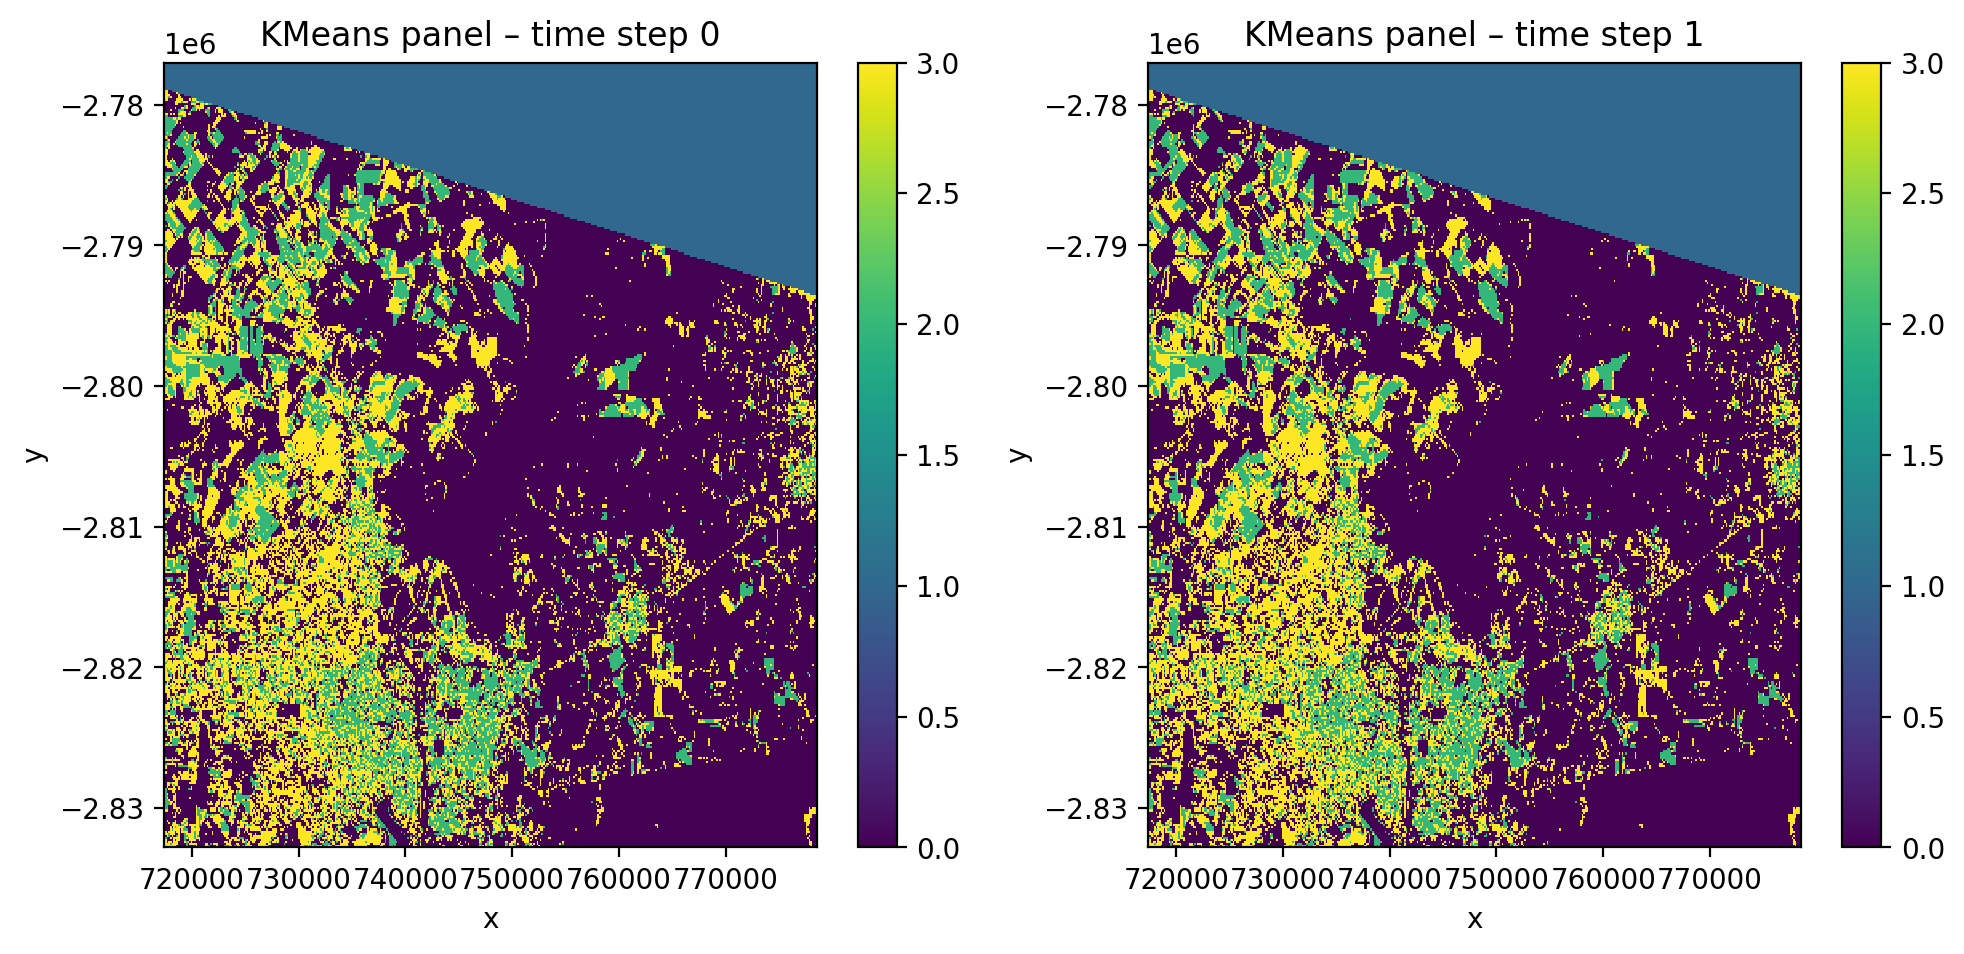

In [11]:
cl_time = Pipeline(
    [
        ('scaler', StandardScaler()),
        ('clf', KMeans(n_clusters=4, random_state=0)),
    ]
)

with gw.config.update(ref_res=150):
    with gw.open(
        [l8_224078_20200518, l8_224078_20200518],
        stack_dim='time',
    ) as src:
        y_cl = fit_predict(
            data=src,
            clf=cl_time,
            temporal_mode='panel',
        )

print('Unsupervised panel output:')
print(f'  Shape: {y_cl.shape}')
print(f'  Dims:  {y_cl.dims}')

fig, axes = plt.subplots(1, 2, dpi=200, figsize=(10, 5))
for i, ax in enumerate(axes):
    y_cl.isel(time=i).plot(robust=True, ax=ax)
    ax.set_title(f'KMeans panel \u2013 time step {i}')
plt.tight_layout(pad=1)
plt.show()

### Compare panel vs flatten side by side

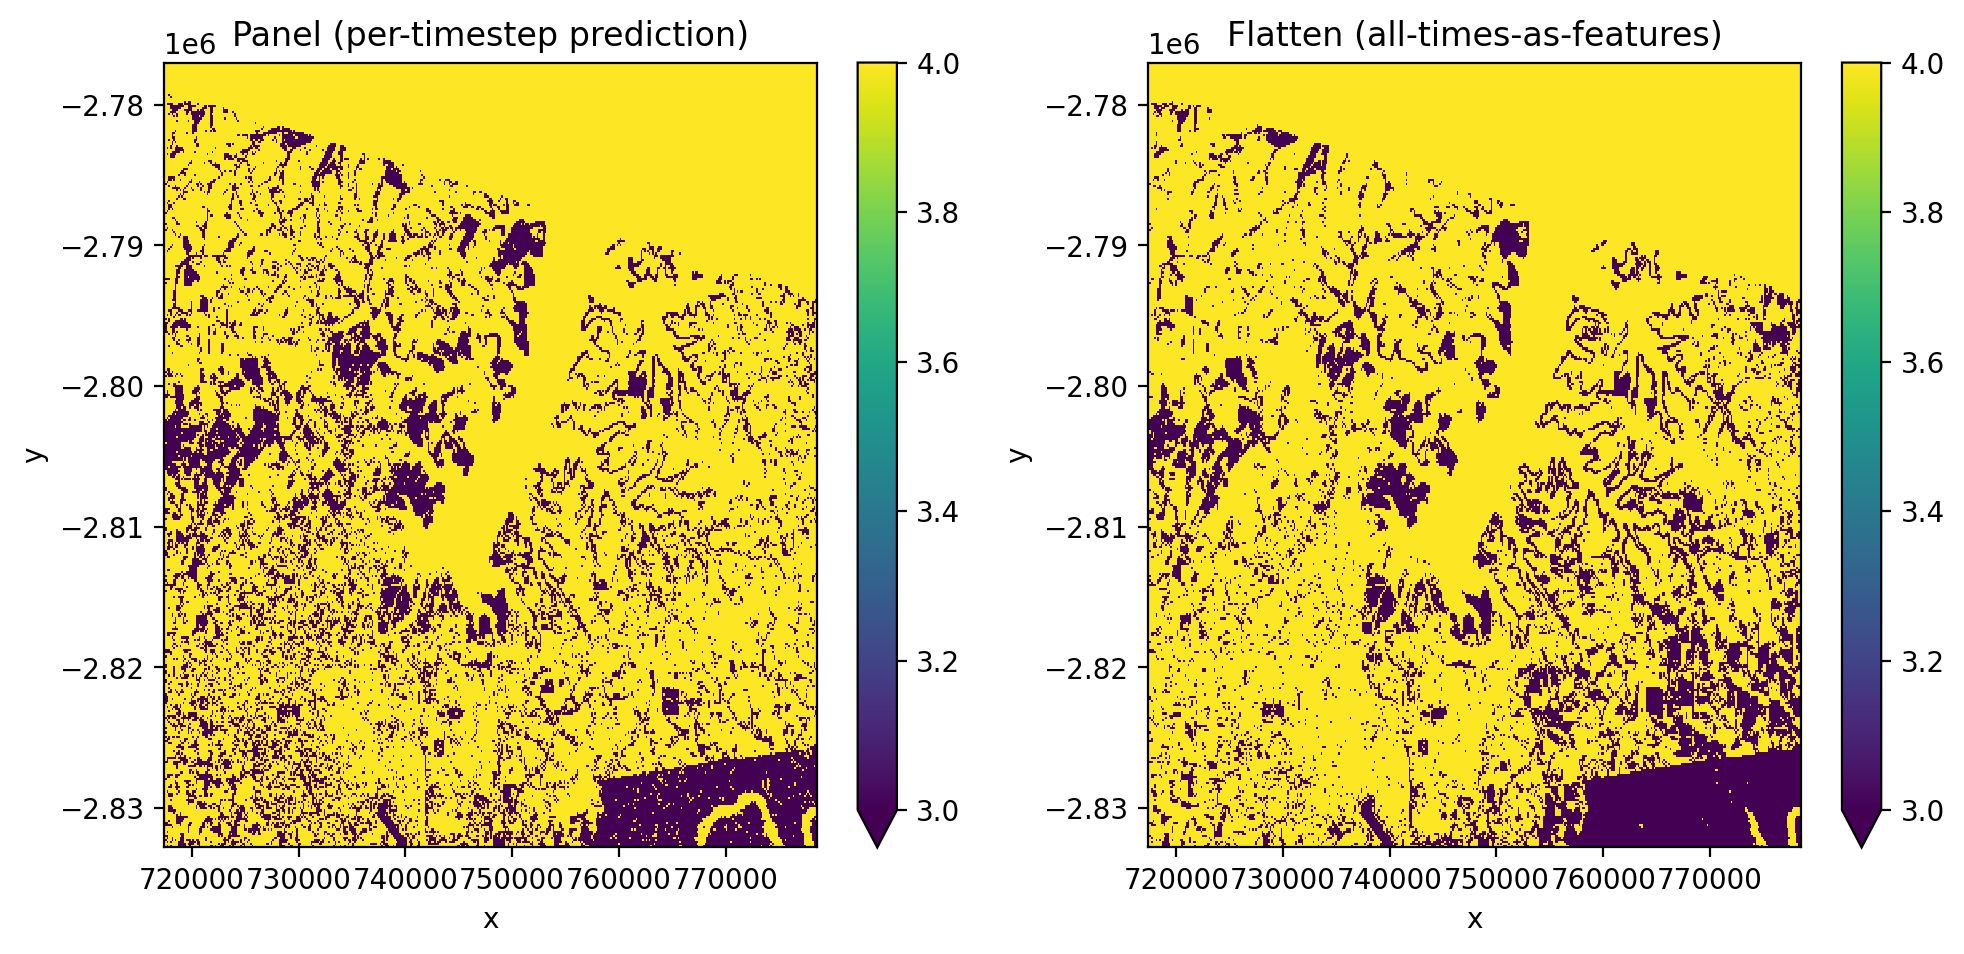

In [12]:
fig, axes = plt.subplots(1, 2, dpi=200, figsize=(10, 5))

y_panel.isel(time=0).plot(robust=True, ax=axes[0])
axes[0].set_title('Panel (per-timestep prediction)')

y_flat.plot(robust=True, ax=axes[1])
axes[1].set_title('Flatten (all-times-as-features)')

plt.tight_layout(pad=1)
plt.show()

---
## Notes

- **`n_classes` is auto-inferred** from the label column during `fit()`. You never need to specify it.
- **Nodata handling**: Pixels with nodata values are automatically masked as NaN in predictions.
- **`ref_res`** controls the output resolution. Use coarser resolution (e.g., 150–300m) for faster demos.
- For production workflows, use more training data and full-resolution imagery.
- Save predictions with `y.gw.save('classification.tif', overwrite=True)`
- See the `dl_classifiers.ipynb` notebook for deep learning classifiers (TabNet, L-TAE, TorchGeo).
- See the `stac.ipynb` notebook for downloading satellite imagery from cloud catalogs.